# **Day 75: Reinforcement Learning**
*Module 11 - Advanced Deep Learning*

In supervised learning a teacher gives the right answer. In **reinforcement learning (RL)** an **agent** acts in an **environment**, receives **rewards**, and must discover by trial and error which actions maximise long-term reward. RL beat world champions at Go, trains robots, optimises data-centre cooling, and fine-tunes large language models (RLHF, Day 76). Environmental applications include irrigation scheduling, reservoir operation and adaptive sampling.

> In reinforcement learning an agent learns by trial and error: it takes actions, receives rewards, and gradually learns a strategy that maximises total reward.
>
> *Example:* An agent that schedules satellite acquisitions learns to prioritise cloud-free areas because those requests earn higher rewards.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
torch.manual_seed(75); rng = np.random.default_rng(75)

## **1. The Framework**
At each time step the agent observes state $s_t$, takes action $a_t$, receives reward $r_{t+1}$ and moves to $s_{t+1}$. A **policy** $\pi(a\mid s)$ chooses actions. The goal is to maximise the expected **discounted return** $G_t = \sum_{k\ge0}\gamma^kr_{t+k+1}$ ($0\le\gamma<1$).
- **Value function** $V^\pi(s) = \mathbb E_\pi[G_t\mid s_t = s]$; **action value** $Q^\pi(s,a) = \mathbb E_\pi[G_t\mid s_t=s, a_t=a]$.
- **Bellman optimality**: $Q^*(s,a) = \mathbb E\big[r + \gamma\max_{a'}Q^*(s', a')\big]$.

## **2. Exploration vs Exploitation: Multi-Armed Bandits**
Five fertiliser treatments with unknown mean yields. Each season we try one. Exploit the best-looking one, or explore others in case they are better?

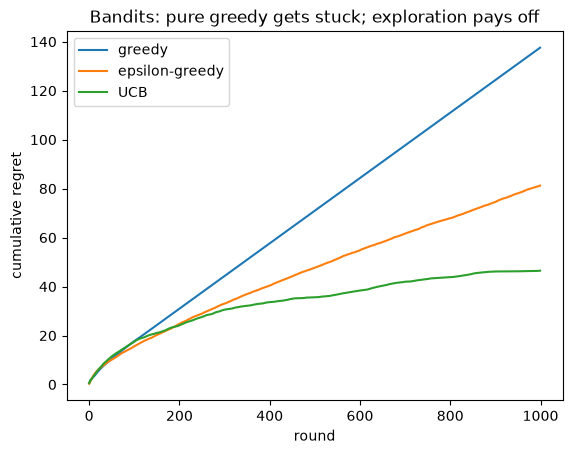

In [2]:
true_means = np.array([3.0, 3.4, 2.8, 3.6, 3.3])
def run_bandit(strategy, n_rounds=1000, eps=0.1, c=1.0, seed=0):
    r = np.random.default_rng(seed); counts = np.zeros(5); values = np.zeros(5); regret = []
    for t in range(1, n_rounds + 1):
        if strategy == "greedy": a = np.argmax(values) if counts.min() > 0 else t - 1
        elif strategy == "epsilon-greedy": a = r.integers(5) if (r.random() < eps or counts.min() == 0) else np.argmax(values)
        else: a = t - 1 if counts.min() == 0 else np.argmax(values + c * np.sqrt(np.log(t) / counts))     # UCB
        reward = r.normal(true_means[a], 0.8); counts[a] += 1; values[a] += (reward - values[a]) / counts[a]
        regret.append(true_means.max() - true_means[a])
    return np.cumsum(regret)
for s in ["greedy", "epsilon-greedy", "UCB"]:
    plt.plot(np.mean([run_bandit(s, seed=k) for k in range(30)], axis=0), label=s)
plt.xlabel("round"); plt.ylabel("cumulative regret"); plt.legend(); plt.title("Bandits: pure greedy gets stuck; exploration pays off"); plt.show()

## **3. A Grid World and Value Iteration**
A 6x6 grid: start at the top-left, goal (+10) at the bottom-right, a hazard zone (-10, e.g. a landslide area) in the middle, and -0.1 per step. Actions: up, down, left, right; with probability 0.1 the move "slips" in a random direction. With a **known model**, **value iteration** repeatedly applies the Bellman optimality update until convergence.

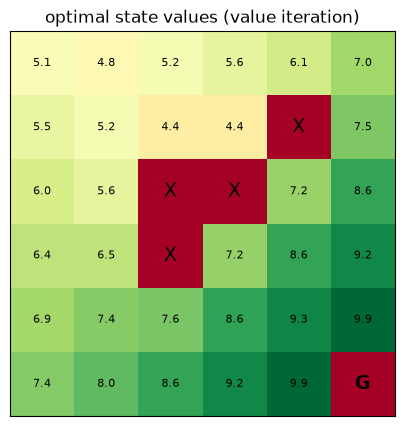

In [3]:
N = 6; ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]; ARROWS = ["^", "v", "<", ">"]
GOAL, HAZARDS = (5, 5), {(2, 2), (2, 3), (3, 2), (1, 4)}
def step(s, a, r=rng, slip=0.1):
    if r.random() < slip: a = r.integers(4)
    ns = (min(max(s[0] + ACTIONS[a][0], 0), N - 1), min(max(s[1] + ACTIONS[a][1], 0), N - 1))
    if ns == GOAL: return ns, 10.0, True
    if ns in HAZARDS: return ns, -10.0, True
    return ns, -0.1, False

def value_iteration(gamma=0.95, slip=0.1, tol=1e-6):
    V = np.zeros((N, N))
    while True:
        delta = 0
        for i in range(N):
            for j in range(N):
                if (i, j) == GOAL or (i, j) in HAZARDS: continue
                q = []
                for a in range(4):
                    val = 0
                    for a2, p in [(a, 1 - slip)] + [(k, slip / 4) for k in range(4)]:
                        ns = (min(max(i + ACTIONS[a2][0], 0), N - 1), min(max(j + ACTIONS[a2][1], 0), N - 1))
                        rew = 10 if ns == GOAL else (-10 if ns in HAZARDS else -0.1)
                        val += p * (rew + (0 if ns == GOAL or ns in HAZARDS else gamma * V[ns]))
                    q.append(val)
                new = max(q); delta = max(delta, abs(new - V[i, j])); V[i, j] = new
        if delta < tol: return V

def plot_policy(ax, Q_or_V, title, is_Q=True):
    grid = Q_or_V.max(-1) if is_Q else Q_or_V
    ax.imshow(grid, cmap="RdYlGn")
    for i in range(N):
        for j in range(N):
            if (i, j) == GOAL: ax.text(j, i, "G", ha="center", va="center", fontsize=14, weight="bold")
            elif (i, j) in HAZARDS: ax.text(j, i, "X", ha="center", va="center", fontsize=14, color="k")
            elif is_Q: ax.text(j, i, ARROWS[int(np.argmax(Q_or_V[i, j]))], ha="center", va="center", fontsize=14)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

V_star = value_iteration()
fig, ax = plt.subplots(figsize=(5, 5)); plot_policy(ax, V_star, "optimal state values (value iteration)", is_Q=False)
for i in range(N):
    for j in range(N):
        if (i, j) != GOAL and (i, j) not in HAZARDS: ax.text(j, i, f"{V_star[i, j]:.1f}", ha="center", va="center", fontsize=8)
plt.show()

## **4. Q-Learning: Learning Without a Model**
In reality we rarely know the transition probabilities. **Q-learning** (Watkins, 1989) learns $Q^*$ directly from experience:
$$Q(s,a) \leftarrow Q(s,a) + \alpha\big[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\big]$$
It is **off-policy**: it learns the greedy policy while behaving epsilon-greedily for exploration.

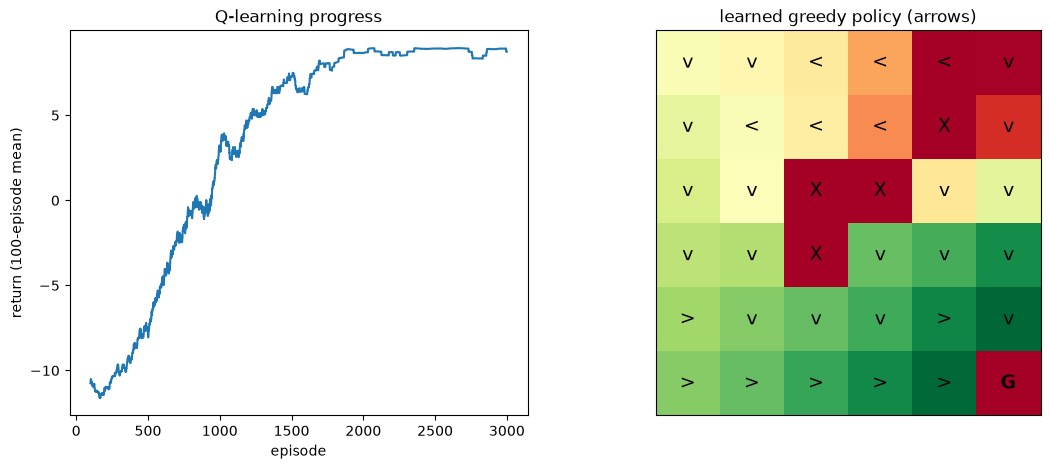

max |V from Q-learning - V from value iteration| on non-terminal cells: 6.93


In [4]:
def q_learning(episodes=3000, alpha=0.1, gamma=0.95, eps_start=1.0, eps_end=0.05, seed=0):
    r = np.random.default_rng(seed); Q = np.zeros((N, N, 4)); returns = []
    for ep in range(episodes):
        eps = max(eps_end, eps_start * (1 - ep / (0.7 * episodes))); s = (0, 0); G, done, steps = 0, False, 0
        while not done and steps < 100:
            a = r.integers(4) if r.random() < eps else int(np.argmax(Q[s]))
            ns, rew, done = step(s, a, r)
            target = rew + (0 if done else gamma * Q[ns].max())
            Q[s][a] += alpha * (target - Q[s][a]); s = ns; G += rew; steps += 1
        returns.append(G)
    return Q, np.array(returns)

Q, rets = q_learning()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(pd.Series(rets).rolling(100).mean()); axes[0].set(xlabel="episode", ylabel="return (100-episode mean)", title="Q-learning progress")
plot_policy(axes[1], Q, "learned greedy policy (arrows)"); plt.show()
print("max |V from Q-learning - V from value iteration| on non-terminal cells:",
      round(np.max([abs(Q[i, j].max() - V_star[i, j]) for i in range(N) for j in range(N) if (i, j) != GOAL and (i, j) not in HAZARDS]), 2))

## **5. Learning an Irrigation Policy**
A simplified crop-water problem. Each week (state = soil-moisture level 0-9 and crop stage 0-3) the farmer chooses: **no irrigation, light, heavy**. Rain is random (more in the monsoon weeks). Reward = yield contribution (penalised when soil is too dry or waterlogged) minus water cost. Q-learning discovers a policy that saves water without stressing the crop.

In [5]:
WEEKS = 16
def irrigation_env_step(moist, week, action, r):
    rain = r.choice([0, 1, 2, 3], p=[0.5, 0.25, 0.15, 0.1] if week < 8 else [0.25, 0.3, 0.25, 0.2])
    moist = int(np.clip(moist + [0, 2, 4][action] + rain - 2, 0, 9))                     # evapotranspiration removes 2 units/week
    stage = min(week // 4, 3); optimum = [5, 6, 6, 4][stage]
    stress = abs(moist - optimum)
    reward = 1.0 - 0.3 * stress - (0.5 if moist >= 9 else 0) - [0, 0.2, 0.45][action]
    return moist, reward

def train_irrigation(episodes=20000, alpha=0.1, gamma=0.98, seed=0):
    r = np.random.default_rng(seed); Q = np.zeros((10, WEEKS, 3))
    for ep in range(episodes):
        eps = max(0.05, 1 - ep / (0.6 * episodes)); m = 5
        for w in range(WEEKS):
            a = r.integers(3) if r.random() < eps else int(np.argmax(Q[m, w]))
            nm, rew = irrigation_env_step(m, w, a, r)
            target = rew + (gamma * Q[nm, w + 1].max() if w + 1 < WEEKS else 0)
            Q[m, w, a] += alpha * (target - Q[m, w, a]); m = nm
    return Q

def evaluate_policy(policy, n=2000, seed=1):
    r = np.random.default_rng(seed); totals, water = [], []
    for _ in range(n):
        m, tot, wat = 5, 0, 0
        for w in range(WEEKS):
            a = policy(m, w, r); m, rew = irrigation_env_step(m, w, a, r); tot += rew; wat += [0, 2, 4][a]
        totals.append(tot); water.append(wat)
    return np.mean(totals), np.mean(water)

Qi = train_irrigation()
policies = {"never irrigate": lambda m, w, r: 0, "always light": lambda m, w, r: 1, "fixed rule (irrigate heavy if moisture < 4)": lambda m, w, r: 2 if m < 4 else 0,
            "Q-learning policy": lambda m, w, r: int(np.argmax(Qi[m, w]))}
pd.DataFrame({k: dict(zip(["mean seasonal reward", "mean water used"], evaluate_policy(p))) for k, p in policies.items()}).T.round(2)

,mean seasonal reward,mean water used
never irrigate,-5.10,0.00
always light,-7.95,32.00
fixed rule (irrigate heavy if moisture < 4),6.80,14.33
Q-learning policy,8.99,13.26


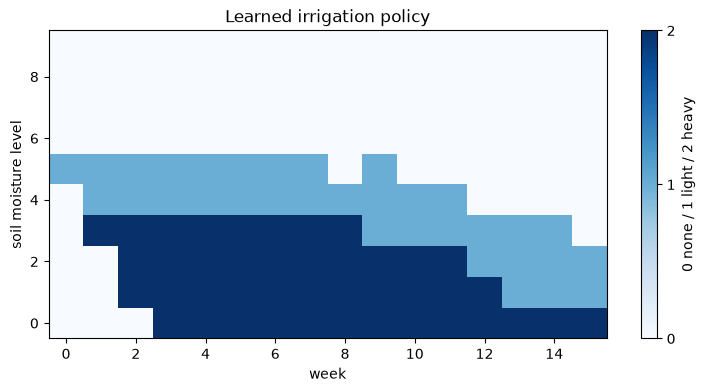

In [6]:
plt.figure(figsize=(9, 4)); plt.imshow(Qi.argmax(-1), cmap="Blues", aspect="auto", origin="lower")
plt.colorbar(ticks=[0, 1, 2], label="0 none / 1 light / 2 heavy"); plt.xlabel("week"); plt.ylabel("soil moisture level"); plt.title("Learned irrigation policy"); plt.show()

# **Part 2: Going Deeper - Deep RL**

Tables fail when states are continuous or huge (images, sensor vectors). **Deep Q-Networks** (Mnih et al., 2015) approximate $Q(s,\cdot)$ with a neural network, stabilised by an **experience replay** buffer and a slowly updated **target network**. **Policy-gradient** methods (REINFORCE, PPO) parameterise the policy directly and follow $\nabla_\theta\mathbb E[G] = \mathbb E[G\,\nabla_\theta\log\pi_\theta(a\mid s)]$.

### DQN on the grid world (state = one-hot position)

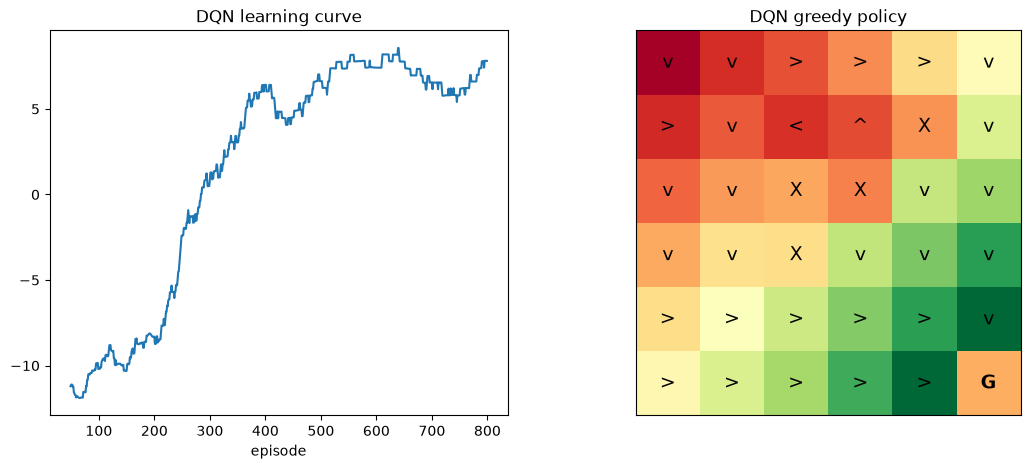

In [7]:
def onehot(s): v = torch.zeros(N * N); v[s[0] * N + s[1]] = 1; return v
qnet = nn.Sequential(nn.Linear(N * N, 64), nn.ReLU(), nn.Linear(64, 4)); target_net = nn.Sequential(nn.Linear(N * N, 64), nn.ReLU(), nn.Linear(64, 4))
target_net.load_state_dict(qnet.state_dict()); opt = torch.optim.Adam(qnet.parameters(), 1e-3)
buffer, r = [], np.random.default_rng(0); returns_dqn = []
for ep in range(800):
    eps = max(0.05, 1 - ep / 500); s, done, G, t = (0, 0), False, 0, 0
    while not done and t < 100:
        with torch.no_grad(): a = r.integers(4) if r.random() < eps else int(qnet(onehot(s)).argmax())
        ns, rew, done = step(s, a, r); buffer.append((onehot(s), a, rew, onehot(ns), float(done))); buffer = buffer[-5000:]
        s, G, t = ns, G + rew, t + 1
        if len(buffer) >= 256:
            batch = [buffer[i] for i in r.integers(0, len(buffer), 64)]
            S, A, R, S2, D = (torch.stack([b[0] for b in batch]), torch.tensor([b[1] for b in batch]), torch.tensor([b[2] for b in batch]),
                              torch.stack([b[3] for b in batch]), torch.tensor([b[4] for b in batch]))
            with torch.no_grad(): y_t = R + 0.95 * (1 - D) * target_net(S2).max(1).values
            loss = F.smooth_l1_loss(qnet(S).gather(1, A[:, None]).squeeze(1), y_t); opt.zero_grad(); loss.backward(); opt.step()
    if ep % 20 == 0: target_net.load_state_dict(qnet.state_dict())
    returns_dqn.append(G)
with torch.no_grad(): Q_dqn = torch.stack([qnet(onehot((i, j))) for i in range(N) for j in range(N)]).view(N, N, 4).numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(pd.Series(returns_dqn).rolling(50).mean()); axes[0].set(title="DQN learning curve", xlabel="episode")
plot_policy(axes[1], Q_dqn, "DQN greedy policy"); plt.show()

### REINFORCE (policy gradient) on a 2-armed bandit-like task
Policy-gradient methods are what RLHF uses (PPO) to fine-tune language models to human preferences.

In [8]:
logits = torch.zeros(5, requires_grad=True); opt = torch.optim.Adam([logits], 0.05); baseline = 0.0
for it in range(1500):
    probs = torch.softmax(logits, 0); a = torch.multinomial(probs, 1).item(); reward = rng.normal(true_means[a], 0.8)
    baseline = 0.99 * baseline + 0.01 * reward                                              # variance-reducing baseline
    loss = -(reward - baseline) * torch.log(probs[a]); opt.zero_grad(); loss.backward(); opt.step()
print("REINFORCE final action probabilities:", torch.softmax(logits, 0).detach().numpy().round(3), "| best arm =", int(np.argmax(true_means)))

REINFORCE final action probabilities: [0.006 0.014 0.003 0.971 0.005] | best arm = 3


### Caveats for real-world RL
Simulators may not match reality (sim-to-real gap); reward design is hard (agents exploit loopholes); exploration in the real world can be costly or unsafe; sample efficiency is low. For environmental management, RL is most useful **inside a validated simulator** (crop or hydrological model), with constraints and human oversight.

## **Practice Problems**
1. Run Q-learning with gamma = 0.5 and gamma = 0.99. How does the learned path change near the hazards?
2. Change the bandit to non-stationary means (they drift slowly). Which strategy adapts best? (Hint: use a constant step size instead of the sample average.)
3. Make water twice as expensive in the irrigation problem and retrain. How does the policy change?
4. *(Advanced)* Implement **SARSA** (on-policy: use the action actually taken next instead of the max) and compare its learned path with Q-learning in the slippery grid (SARSA tends to keep a safer distance from hazards).

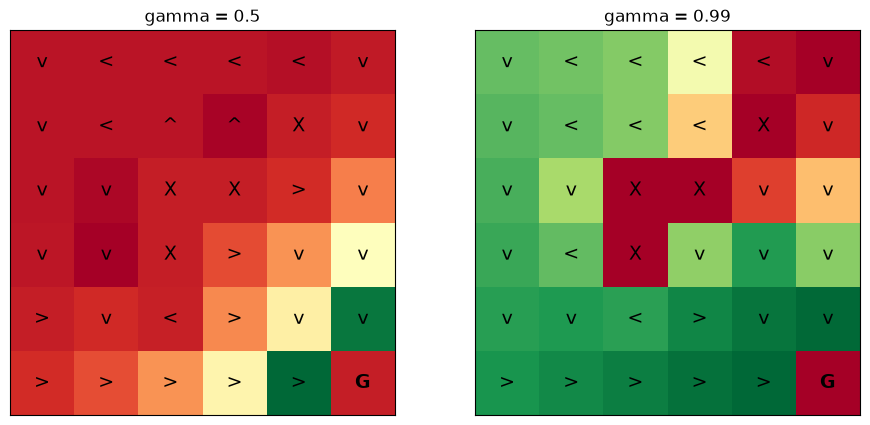

heavy-irrigation share: normal cost 0.262 | double cost 0.244


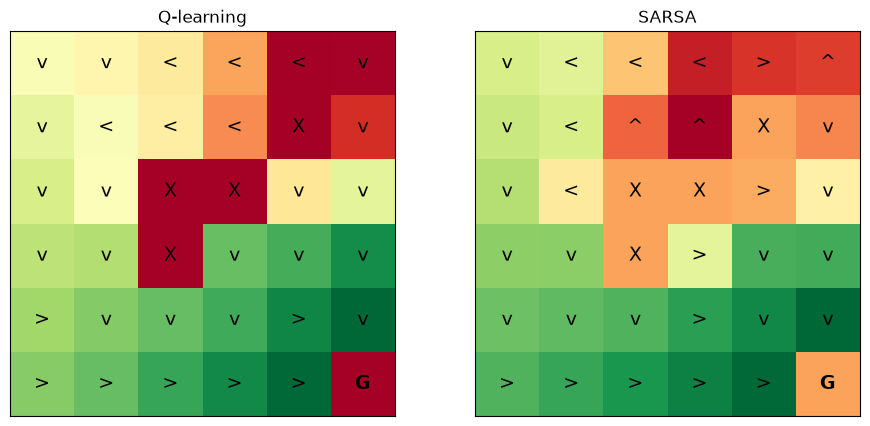

In [9]:
# Solution 2 is an open exercise: add a small random walk to true_means each round and replace the sample-average update by values[a] += 0.1 * (reward - values[a]).
# Solution 1
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, g in zip(axes, [0.5, 0.99]): plot_policy(ax, q_learning(gamma=g)[0], f"gamma = {g}")
plt.show()
# Solution 3
_orig = irrigation_env_step
def irrigation_env_step(moist, week, action, r):
    m, rew = _orig(moist, week, action, r); return m, rew - [0, 0.2, 0.45][action]       # water cost doubled
Q2 = train_irrigation(); irrigation_env_step = _orig
print("heavy-irrigation share: normal cost", round(np.mean(Qi.argmax(-1) == 2), 3), "| double cost", round(np.mean(Q2.argmax(-1) == 2), 3))
# Solution 4
def sarsa(episodes=3000, alpha=0.1, gamma=0.95, seed=0):
    r = np.random.default_rng(seed); Q = np.zeros((N, N, 4))
    pick = lambda s, eps: r.integers(4) if r.random() < eps else int(np.argmax(Q[s]))
    for ep in range(episodes):
        eps = max(0.05, 1 - ep / (0.7 * episodes)); s = (0, 0); a = pick(s, eps); done, t = False, 0
        while not done and t < 100:
            ns, rew, done = step(s, a, r); na = pick(ns, eps)
            Q[s][a] += alpha * (rew + (0 if done else gamma * Q[ns][na]) - Q[s][a]); s, a, t = ns, na, t + 1
    return Q
fig, axes = plt.subplots(1, 2, figsize=(11, 5)); plot_policy(axes[0], Q, "Q-learning"); plot_policy(axes[1], sarsa(), "SARSA"); plt.show()

## **Key References**
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press (free online).
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Mnih, V. et al. (2015). Human-level control through deep reinforcement learning. *Nature*, 518, 529-533.
- Williams, R. J. (1992). Simple statistical gradient-following algorithms for connectionist reinforcement learning. *Machine Learning*, 8, 229-256.
- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal policy optimization algorithms. arXiv:1707.06347.
- Auer, P., Cesa-Bianchi, N., & Fischer, P. (2002). Finite-time analysis of the multiarmed bandit problem. *Machine Learning*, 47, 235-256 (UCB).